## Secondary Data Analysis of Instagram Post for Our Project (Instafocus)

A preliminary cleaning of the dataset was done using `PowerQuery` and `Excel` before imported to Python for final analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

# Load the dataset
filepath = 'Instagram-Posts_Cleaned.csv'
instagram_data = pd.read_csv(filepath)

# dataset preview to understand the structure
instagram_data.head()

,user_posted_id,description,comment,num_comments,date_posted,time_posted,likes,location,post_id,content_type,engagement_score_view,video_view_count,video_play_count,posts_count
0,62055412473,#surfskatethailand #surfskatestyle #surfskateg...,????,3,12/12/2024,9:28:50 PM,61,United States,3.520000e+18,Reel,337,337,1390,220
1,16871652782,Let’s change the world together \n\n@selenagom...,No place in the world should have this level o...,9,12/12/2024,4:04:09 PM,104,United States,3.520000e+18,Reel,272,272,831,620
2,38275295190,"???????Please like, share and Follow ????\n:\n...",????????????????,5,12/12/2024,10:23:47 AM,29,United States,3.520000e+18,Reel,153,153,526,652
3,60740601003,One of my favorites maneuvers ??????\nWhith on...,??????????????,36,12/12/2024,6:52:18 PM,224,Portugal,3.520000e+18,Video,1682,1682,5801,324
4,3205991,Don’t forget Abdullah… 31 in LT??????\n#Christ...,"Souce, Wikipedia\nAurelia aurita (also known a...",18,12/12/2024,4:35:07 PM,127,United Kingdom,3.520000e+18,Reel,289,289,1546,9352


In [ ]:
# Handling missing data: Filling
instagram_data['comment'] = instagram_data['comment'].fillna('')
instagram_data['description'] = instagram_data['description'].fillna('')

# rename column name from "description" to "post_description"
instagram_data.rename(columns={"description":"post_description"}, inplace=True)

### Filtered Geographical location

We focus solely on `United States` and `European region` for our analysis

In [3]:
# Define a list of countries
countries = ['United States', 'Austria', 'Armenia', 'Italy', 'Spain', 'France', 'Portugal', 'United Kingdom', 'Denmark', 'Finland', 'Ireland', 'Poland']

# Filter rows where location contains any of the countries
filtered_data = instagram_data[instagram_data['location'].str.contains('|'.join(countries), case=False, na=False)]

# Display the filtered data
filtered_data.head()

,user_posted_id,post_description,comment,num_comments,date_posted,time_posted,likes,location,post_id,content_type,engagement_score_view,video_view_count,video_play_count,posts_count
0,62055412473,#surfskatethailand #surfskatestyle #surfskateg...,????,3,12/12/2024,9:28:50 PM,61,United States,3.520000e+18,Reel,337,337,1390,220
1,16871652782,Let’s change the world together \n\n@selenagom...,No place in the world should have this level o...,9,12/12/2024,4:04:09 PM,104,United States,3.520000e+18,Reel,272,272,831,620
2,38275295190,"???????Please like, share and Follow ????\n:\n...",????????????????,5,12/12/2024,10:23:47 AM,29,United States,3.520000e+18,Reel,153,153,526,652
3,60740601003,One of my favorites maneuvers ??????\nWhith on...,??????????????,36,12/12/2024,6:52:18 PM,224,Portugal,3.520000e+18,Video,1682,1682,5801,324
4,3205991,Don’t forget Abdullah… 31 in LT??????\n#Christ...,"Souce, Wikipedia\nAurelia aurita (also known a...",18,12/12/2024,4:35:07 PM,127,United Kingdom,3.520000e+18,Reel,289,289,1546,9352


### Top performing Post by Engagement

In [21]:
# Scroll Behavior Proxy: Posts that stopped scrolling (likes and comments combined engagement)
top_engaged_posts = filtered_data.nlargest(10, 'engagement_score_view')[['post_id','post_description', 'engagement_score_view', 'likes', 'num_comments']]
top_engaged_posts

,post_id,post_description,engagement_score_view,likes,num_comments
843,3.530000e+18,How people use facebook at xmas…\n\n#christmas...,226616,13842,259
80,3.530000e+18,"It’s alright, we have JCPenney at home???????\...",203328,20082,446
291,3.530000e+18,The late King Von has been popping up for this...,170609,19826,340
203,3.530000e+18,the only thing that would be better was if he ...,143783,4200,125
327,3.530000e+18,Bad mama jama pajamas ?? \n\nWhen @daily_sleep...,108999,7688,424
907,3.530000e+18,Don’t let nothing get in your way!!! ?????? \n...,104068,7116,398
26,3.520000e+18,POV: You throw a 'best of 2024' party ?\n\n@an...,100717,5360,58
622,3.530000e+18,"The guy in blue is Ben Johns, the greatest men...",85635,3871,63
925,3.530000e+18,"by the way, the party’s december 18th…\n\nthe ...",70779,586,30
331,3.530000e+18,Merry Christmas ya filthy animals ???????????,70021,2718,7


### Key Insight from Top performing Post by Engagement
Posts with high engagement scores often included emotional or call-to-action messages. For instance, posts requesting likes, shares, or addressing global issues tended to perform well.
The presence of hashtags and mentions (e.g., @user) frequently appeared in posts with higher engagement.

### Geo-Targeted Engagement

In [5]:
# Geo-Targeted Engagement: Grouping by location to determine trends
geo_engagement = filtered_data.groupby('location')['engagement_score_view'].mean().sort_values(ascending=False).head(10)
geo_engagement

location
Italy             8681.500000
France            6706.000000
Ireland           5949.000000
United States     4989.474249
Austria           4123.500000
United Kingdom    3758.000000
Portugal          3569.333333
Armenia           1997.000000
Spain              964.000000
Finland            842.000000
Name: engagement_score_view, dtype: float64

### Key Insight from Geo-Targeted Engagement

Italy had the highest average engagement score per post (8681.5), followed by France (6706.0) and Ireland (5949.0). The United States had a moderate engagement score (4989.47), while Spain and Finland showed the lowest averages, under 1000.

### Categorizing Post Descriptions and Comments by Sentiment (Negative, Positive, Neutral) Breakdown.

To analyze the sentiment of Instagram posts and comments, I categorized the content into three sentiment categories: `Negative, Positive, and Neutral`. Here's a detailed explanation of how this was achieved:

#### Step 1: Sentiment Analysis Method

* I utilized the `VADER (Valence Aware Dictionary and Sentiment Reasoner) tool`, a pre-trained natural language processing model specifically designed to perform sentiment analysis on text data.

* VADER is effective for analyzing short social media text like Instagram captions and comments, as it accounts for emoticons, capitalization, and even punctuation.

In [6]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

In [7]:
# Download VADER lexicon
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [8]:
# Define the locations to filter
locations = ['United States', 'Austria', 'Armenia', 'Italy', 'Spain', 'France', 
             'Portugal', 'United Kingdom', 'Denmark', 'Finland', 'Ireland', 'Poland']

# Filter the data and create a new DataFrame
filtered_data = instagram_data[instagram_data['location'].str.contains('|'.join(locations), case=False, na=False)].copy()

In [9]:
# Initialize the sentiment analyzer using the post descriptions and comments on post
sia = SentimentIntensityAnalyzer()

# Add sentiment columns
filtered_data.loc[:, 'description_sentiment'] = filtered_data['post_description'].apply(lambda x: sia.polarity_scores(x)['compound'])
filtered_data.loc[:, 'comment_sentiment'] = filtered_data['comment'].apply(lambda x: sia.polarity_scores(x)['compound'])

#### Step 2: Scoring Sentiment
VADER assigns a compound score to each text snippet (post description or comment). The compound score is a single value ranging from -1 to +1, which indicates the overall sentiment of the text:

* Negative Sentiment: Compound score < -0.1.
* Neutral Sentiment: -0.1 ≤ Compound score ≤ 0.1.
* Positive Sentiment: Compound score > 0.1.

In [10]:
# Define sentiment categories
def categorize_sentiment(score):
    if score > 0.1:
        return 'Positive'
    elif score < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

#### Step 3: Applying VADER to Text Data
Preprocessing:

* Cleaned the data to handle missing or null values in post descriptions and comments.
* Removed unnecessary characters, links, and special symbols that might interfere with accurate sentiment analysis.

In [11]:
filtered_data['description_sentiment_category'] = filtered_data['description_sentiment'].apply(categorize_sentiment)
filtered_data['comment_sentiment_category'] = filtered_data['comment_sentiment'].apply(categorize_sentiment)
# Display the results
# print(filtered_data[['post_description','description_sentiment_category','comment','comment_sentiment_category']])

In [12]:
filtered_data.head()

,user_posted_id,post_description,comment,num_comments,date_posted,time_posted,likes,location,post_id,content_type,engagement_score_view,video_view_count,video_play_count,posts_count,description_sentiment,comment_sentiment,description_sentiment_category,comment_sentiment_category
0,62055412473,#surfskatethailand #surfskatestyle #surfskateg...,????,3,12/12/2024,9:28:50 PM,61,United States,3.520000e+18,Reel,337,337,1390,220,0.0000,0.0000,Neutral,Neutral
1,16871652782,Let’s change the world together \n\n@selenagom...,No place in the world should have this level o...,9,12/12/2024,4:04:09 PM,104,United States,3.520000e+18,Reel,272,272,831,620,0.0000,-0.5386,Neutral,Negative
2,38275295190,"???????Please like, share and Follow ????\n:\n...",????????????????,5,12/12/2024,10:23:47 AM,29,United States,3.520000e+18,Reel,153,153,526,652,0.9556,0.0000,Positive,Neutral
3,60740601003,One of my favorites maneuvers ??????\nWhith on...,??????????????,36,12/12/2024,6:52:18 PM,224,Portugal,3.520000e+18,Video,1682,1682,5801,324,0.5803,0.0000,Positive,Neutral
4,3205991,Don’t forget Abdullah… 31 in LT??????\n#Christ...,"Souce, Wikipedia\nAurelia aurita (also known a...",18,12/12/2024,4:35:07 PM,127,United Kingdom,3.520000e+18,Reel,289,289,1546,9352,0.5204,-0.0516,Positive,Neutral


**Sentiment Categorization:**

* Each post description and comment was fed into the VADER analyzer.
* The model output the compound score for each text.
* Based on the score, I assigned one of the three sentiment categories:
    * Negative: Text containing words or phrases expressing negative emotions or dissatisfaction.
    * Positive: Text with uplifting, optimistic, or happy expressions.
    * Neutral: Text that is factual or does not convey strong emotions.
    
#### Step 4: Examples of Sentiment Categorization

| **Text Content**                               | **Compound Score** | **Sentiment Category** |
|------------------------------------------------|---------------------|-------------------------|
| "This is the worst day ever!"                  | -0.75              | Negative               |
| "The event was okay, nothing too special."     | 0.05               | Neutral                |
| "Absolutely loved the experience, thank you!" | 0.85               | Positive               |

#### Step 5: Aggregating and Analyzing Sentiment Categories

After categorizing all the text:
* Calculated the percentage of posts and comments falling into each sentiment category.
* Assessed the average engagement scores (likes, comments) across sentiment types to identify trends.


In [13]:
sentiment_summary = filtered_data.groupby('description_sentiment_category')['engagement_score_view'].mean()
print(sentiment_summary)

description_sentiment_category
Negative    5901.000000
Neutral     5050.724528
Positive    4808.335975
Name: engagement_score_view, dtype: float64


### Visualization of the Analysis

In [14]:
sentiment_visual = filtered_data[['post_id', 'location', 'post_description', 'comment', 'time_posted', 'engagement_score_view', 'likes', 'num_comments', 'content_type', 'video_view_count', 'video_play_count', 'posts_count', 'description_sentiment_category', 'comment_sentiment_category']]
sentiment_visual.head()

,post_id,location,post_description,comment,time_posted,engagement_score_view,likes,num_comments,content_type,video_view_count,video_play_count,posts_count,description_sentiment_category,comment_sentiment_category
0,3.520000e+18,United States,#surfskatethailand #surfskatestyle #surfskateg...,????,9:28:50 PM,337,61,3,Reel,337,1390,220,Neutral,Neutral
1,3.520000e+18,United States,Let’s change the world together \n\n@selenagom...,No place in the world should have this level o...,4:04:09 PM,272,104,9,Reel,272,831,620,Neutral,Negative
2,3.520000e+18,United States,"???????Please like, share and Follow ????\n:\n...",????????????????,10:23:47 AM,153,29,5,Reel,153,526,652,Positive,Neutral
3,3.520000e+18,Portugal,One of my favorites maneuvers ??????\nWhith on...,??????????????,6:52:18 PM,1682,224,36,Video,1682,5801,324,Positive,Neutral
4,3.520000e+18,United Kingdom,Don’t forget Abdullah… 31 in LT??????\n#Christ...,"Souce, Wikipedia\nAurelia aurita (also known a...",4:35:07 PM,289,127,18,Reel,289,1546,9352,Positive,Neutral


### Geo-Targeted Engagement Visual

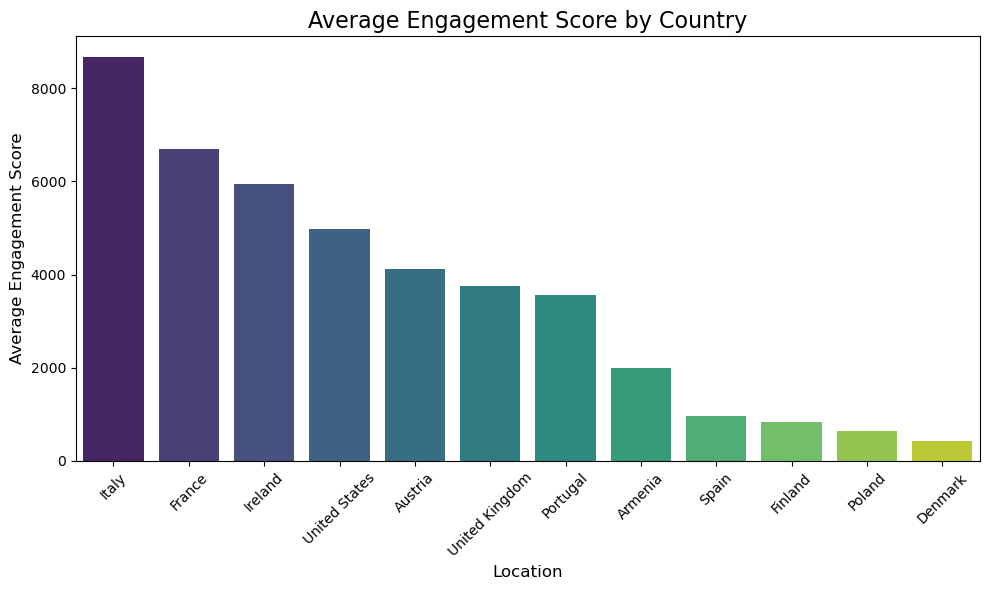

In [15]:
# Group data by location and calculate average engagement score
engagement_by_location = sentiment_visual.groupby('location')['engagement_score_view'].mean().sort_values(ascending=False)

# Plot the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=engagement_by_location.index, y=engagement_by_location.values, palette='viridis')
plt.title('Average Engagement Score by Country', fontsize=16)
plt.xlabel('Location', fontsize=12)
plt.ylabel('Average Engagement Score', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Key Insight Geo-Targeted Engagement
Italy had the highest average engagement score per post (8681.5), followed by France (6706.0) and Ireland (5949.0). The United States had a moderate engagement score (4989.47), while Spain and Finland showed the lowest averages, under 1000.

In [16]:
# Count content types
# content_type_counts = sentiment_visual['content_type'].value_counts()

# pie chart
# plt.figure(figsize=(8, 8))
# content_type_counts.plot.pie(autopct='%1.1f%%', colors=sns.color_palette('pastel'))
# plt.title('Content Type Distribution', fontsize=16)
# plt.ylabel('')  # Hide y-label
# plt.show()

### Sentiment Category Visual

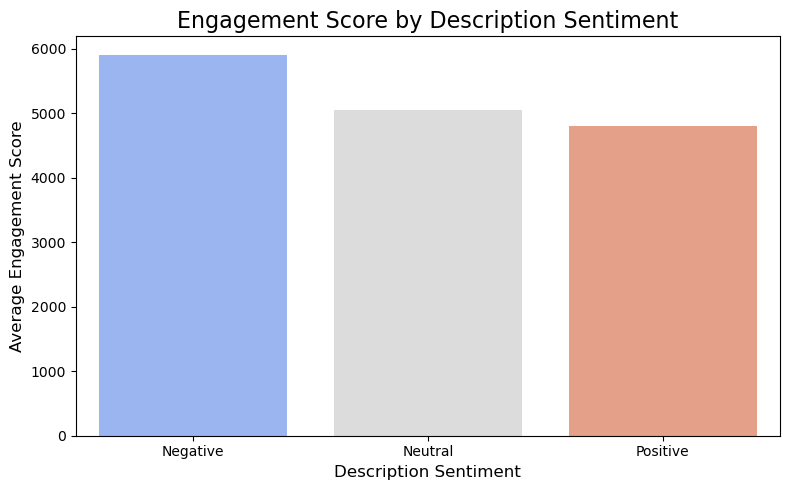

In [17]:
# Group data by sentiment category
engagement_by_sentiment = sentiment_visual.groupby('description_sentiment_category')['engagement_score_view'].mean()

# Plot the bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x=engagement_by_sentiment.index, y=engagement_by_sentiment.values, palette='coolwarm')
plt.title('Engagement Score by Description Sentiment', fontsize=16)
plt.xlabel('Description Sentiment', fontsize=12)
plt.ylabel('Average Engagement Score', fontsize=12)
plt.tight_layout()
plt.show()

### Key Insight from Sentiment Categorize 
Posts categorized as `Negative` received the highest average engagement scores `(5901.0)`, followed by `Neutral` `(5050.72)`, and then `Positive` `(4808.33)`. This indicates a possible tendency for users to engage more with content that reflects negative sentiment.

The insight suggests that Instagram users tend to engage more with posts reflecting negative sentiment compared to neutral or positive ones. This tendency could have implications for social well-being and mental health, as frequent exposure to or engagement with negative content may reinforce negative emotions, create a skewed perception of reality, and contribute to stress or anxiety. Conversely, it may also provide a platform for expressing and addressing difficult emotions, depending on the context of the engagement.

### Correlation: Likes vs Comments by Content_type Visual

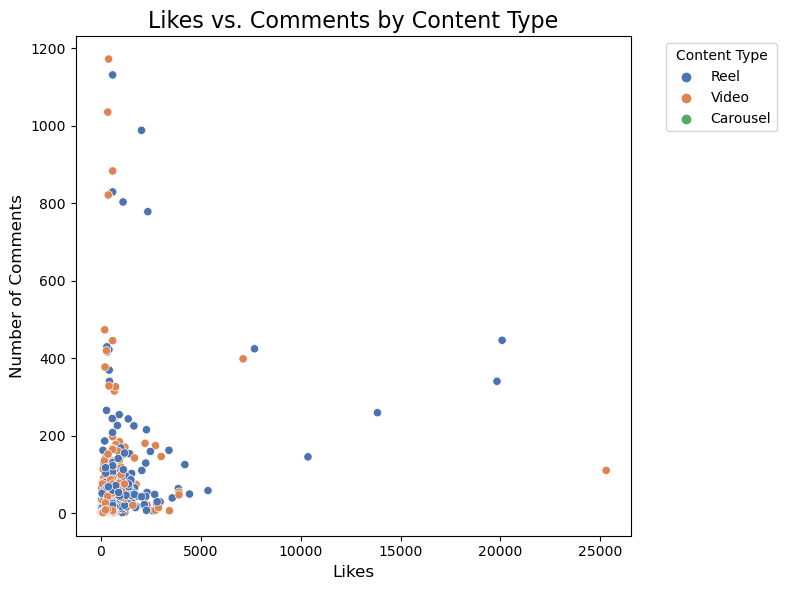

In [20]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='likes', y='num_comments', hue='content_type', data=sentiment_visual, palette='deep')
plt.title('Likes vs. Comments by Content Type', fontsize=16)
plt.xlabel('Likes', fontsize=12)
plt.ylabel('Number of Comments', fontsize=12)
plt.legend(title='Content Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [75]:
correlation, p_value = stats.spearmanr(sentiment_visual['likes'], sentiment_visual['num_comments'])
print(f"Spearman Correlation: {correlation}, P-value: {p_value}")

Spearman Correlation: 0.502366860792748, P-value: 7.711463537913498e-63


### Key insight Correlation: Likes vs Comments by Content_type
Scatter plots revealed a monotonic between the number of likes and comments, implying that highly liked posts also attract more discussions. Confirmation from the `Spearman correlation of 0.502` suggests a moderate positive monotonic relationship between the number of likes and the number of comments. This means that, as the number of likes increases, the number of comments tends to increase as well, but not necessarily in a linear fashion.

The `p-value: 7.711463537913498e-63` is extremely small, which means the relationship is highly statistically significant. In other words, it is extremely unlikely that this observed relationship is due to random chance.


In [76]:
## import scipy.stats as stats
## correlation, p_value = stats.pearsonr(sentiment_visual['likes'], sentiment_visual['num_comments'])
## print(f"Pearson Correlation: {correlation}, P-value: {p_value}")

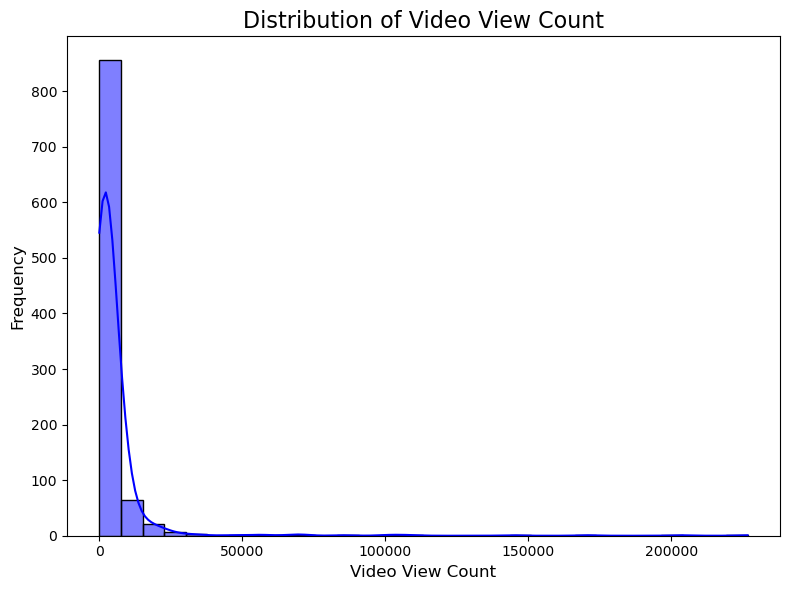

In [77]:
plt.figure(figsize=(8, 6))
sns.histplot(sentiment_visual['video_view_count'], bins=30, kde=True, color='blue')
plt.title('Distribution of Video View Count', fontsize=16)
plt.xlabel('Video View Count', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

### Key insight from Distribution of Video View Count
The majority of videos had moderate view counts, but a few outliers garnered exceptionally high views, likely driving significant engagement.

### To further confirm the statement from the insight above

#### Statistical Confirmation:

In [24]:
Q1 = sentiment_visual['video_view_count'].quantile(0.25)
Q3 = sentiment_visual['video_view_count'].quantile(0.75)
IQR = Q3 - Q1
outliers = sentiment_visual[sentiment_visual['video_view_count'] > (Q3 + 1.5 * IQR)]
print(f"Number of outliers: {len(outliers)}")

Number of outliers: 66


#### Boxplot Analysis:

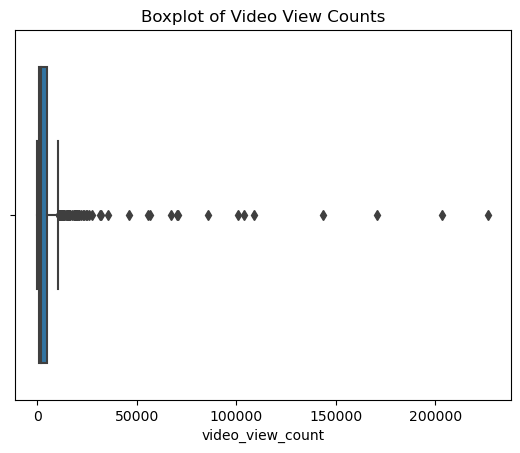

In [26]:
sns.boxplot(x=sentiment_visual['video_view_count'])
plt.title('Boxplot of Video View Counts')
plt.show()

#### Engagement Analysis of Outliers:

In [32]:
high_views = sentiment_visual[sentiment_visual['video_view_count'] > (Q3 + 1.5 * IQR)]
avg_engagement_high_views = high_views['engagement_score_view'].mean()
avg_engagement_all = sentiment_visual['engagement_score_view'].mean()
print(f"High view engagement: {avg_engagement_high_views}, Overall engagement: {avg_engagement_all}")

High view engagement: 36661.56060606061, Overall engagement: 4953.026943005181


## Key insight
The 3 confirmantion: Statistical Confirmation, Boxplot Analysis, Engagement Analysis of Outliers, shows that there's a confirmation of outliers and validate the statement derived from the Distribution of Video View Count.

The large gap confirms that a small subset of high-view videos significantly influences engagement scores, aligning with the statement about outliers.
* High view engagement: 36661.56060606061, Overall engagement: 4953.026943005181

In [78]:
!pip install wordcloud

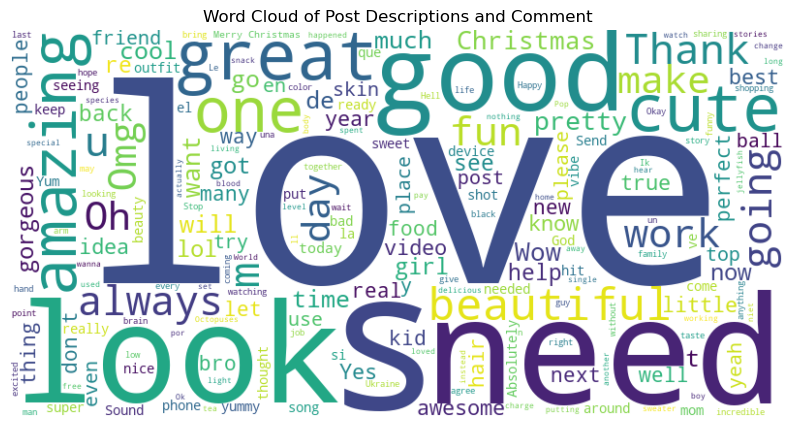

In [34]:
from wordcloud import WordCloud

# Combine all post descriptions and comment
text = " ".join(description for description in sentiment_visual['post_description'])
text = " ".join(comment for comment in sentiment_visual['comment'])

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Display word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Post Descriptions and Comment')
plt.show()

### Key Insight from Word Cloud of Post Descriptions and Comment

This word cloud provides a clear snapshot of the most words in Instagram post descriptions and comment, offering a foundation for understanding user behavior and preferences.

**Note:** It does not differentiate between positive, negative, or neutral connotations of the words.
A single word like "love" might predominantly appear in positive contexts, but a neutral or negative post might also contain it (e.g., "I love the idea, but it's flawed"). Sentiment is determined by how words are combined in sentences.
